In [57]:
import pandas as pd
from fuzzywuzzy import fuzz
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm

# EJERCICIO 5

Un cliente lo contrató como científico de datos para que estudie la posible asociación entre la inversión en publicidad que realiza su empresa y las ventas de un producto particular. El conjunto de datos de publicidad advertising.csv contiene información acerca de las ventas de ese producto en 200 mercados diferentes, junto con presupuestos publicitarios para el producto para tres medios diferentes: televisión, radio y periódicos/diarios.

In [58]:
advertising = pd.read_csv("datasets/Parte_2/advertising.csv")
advertising.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


### Punto 1
Calcula la matriz de correlaciones lineales entre todas las variables del dataset. Que predictories parecen estar mas asociados con sales?

In [59]:
matriz_corr = advertising.corr().round(2)
matriz_corr

,TV,Radio,Newspaper,Sales
TV,1.00,0.05,0.06,0.90
Radio,0.05,1.00,0.35,0.35
Newspaper,0.06,0.35,1.00,0.16
Sales,0.90,0.35,0.16,1.00


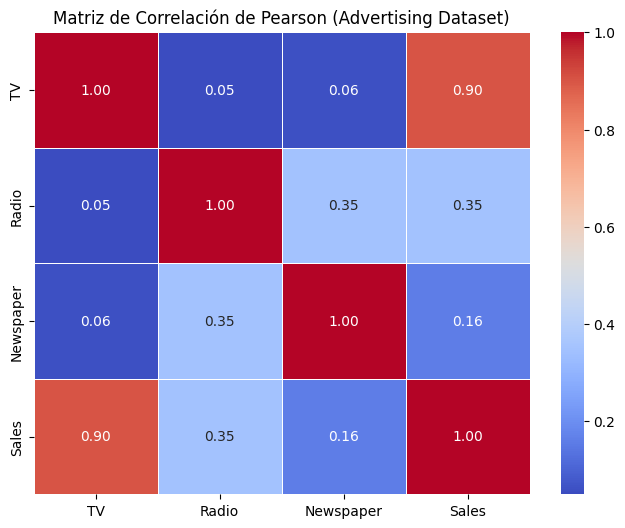

In [60]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, 
            annot=True,       # Muestra el número dentro de cada celda
            cmap='coolwarm',  # Escala de colores (Rojo=Positivo, Azul=Negativo)
            fmt=".2f",        # Limita a 2 decimales
            linewidths=0.5)   # Agrega una pequeña línea divisoria entre celdas

plt.title('Matriz de Correlación de Pearson (Advertising Dataset)')
plt.show()

### Punto 2
Ajusta un modelo de regresion lineal multiple para sales usando los tres predictores: TV, Radio, Newspaper. 
Cuales predictores son estadisticamente significativos al 5%?

In [61]:
modelo1 = smf.ols(formula= 'Sales ~ TV + Radio + Newspaper', data=advertising).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                lun, 08 jun 2026   Prob (F-statistic):           8.13e-99
Time:                        09:42:02   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6251      0.308     15.041      0.0

### Punto 3
Reajusta el modelo eliminando el o los predictores no significativos.

In [62]:
modelo2 = smf.ols(formula= 'Sales ~ TV + Radio', data=advertising).fit()  #Ajustamos Modelo Reducido
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                lun, 08 jun 2026   Prob (F-statistic):          2.39e-100
Time:                        09:42:02   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6309      0.290     15.952      0.0

    El coeficiente de la variable TV es 0.0544. Esto significa que, manteniendo constante la inversión en Radio, por cada unidad monetaria adicional que se invierta en publicidad de TV, se espera que las ventas del producto aumenten en promedio 0.0544 unidades.

Usando el modelo reducido, estima las ventas esperadas para un mercado con inversion de 150 mil USD en TV, 30 mil USD en Radio y 60 mil USD en periodicos.

Prediccion:

In [63]:
# el metodo .predict necesita de un objeto de tipo df, por lo tanto armamos uno con, para cada uno los predictores, 
# el valor para el que quiero predecir la respuesta.
datos_prediccion = pd.DataFrame({'TV' : [150],
                                'Radio' : [30]})
# ponerle o no el valor para newspaper, es indistinto ya que este predictor no se encuentra en el modelo

modelo2.predict(datos_prediccion).round(2)

0    16.01
dtype: float64

    Si el local invierte 150 unidades en publicidad de TV y 30 unidades en Radio, el modelo predice que se obtendrá un total estimado de 16.01 unidades en Ventas, independientemente de lo que se decida invertir en periódicos (ya que esta variable no altera el resultado).

PUNTO 4

Realice un gráfico para representar la distribución de los residuos del modelo y comente brevemente las características de la misma. ¿Podría suponerse que se cumple el supuesto de normalidad?

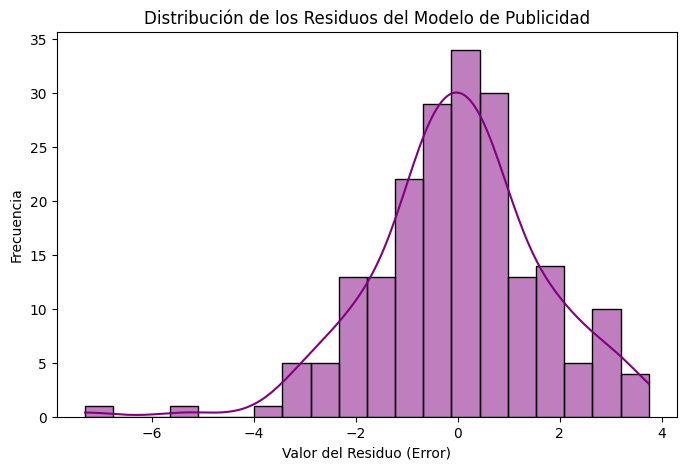

In [64]:
# 1. Extraemos los residuos del modelo usando el atributo .resid
residuos = modelo2.resid

# 2. Graficamos la distribución. Usamos el parametro kde=True para graficar la curva
plt.figure(figsize=(8, 5))
sns.histplot(residuos, kde=True, bins=20, color='purple') 

# Añadimos etiquetas para que quede prolijo
plt.title('Distribución de los Residuos del Modelo de Publicidad')
plt.xlabel('Valor del Residuo (Error)')
plt.ylabel('Frecuencia')
plt.show()

    l observar el histograma y la curva de densidad, vemos que la distribución de los residuos tiene una forma de campana bastante simétrica y, lo más importante, su pico máximo se encuentra fuertemente centrado en el valor cero. Aunque presenta una levísima cola hacia los valores negativos, su comportamiento general se asemeja mucho a una distribución normal. Por lo tanto, sí se puede suponer que se cumple el supuesto de normalidad de los residuos, lo que nos da luz verde para confiar en las estimaciones e inferencias de nuestro modelo ajustado.

-----------------------------------------------------------------------------------------------------------------------------------------------

# EJERCICIO 1

In [65]:
student_data = pd.read_csv("datasets/Parte_2/student_data.csv")
student_data = student_data.drop(columns='Unnamed: 0')
student_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   hours_studied  245 non-null    float64
 1   exam_scores    245 non-null    float64
dtypes: float64(2)
memory usage: 4.0 KB


In [66]:
student_data.head(15)

,hours_studied,exam_scores
0,9.3,63.1
1,23.9,90.4
2,12.9,63.2
3,26.6,87.8
4,28.3,92.9
5,2.3,53.6
6,16.3,71.5
7,26.9,93.6
8,17.0,74.1
9,14.2,68.4


PUNTO 1

<Axes: xlabel='hours_studied', ylabel='exam_scores'>

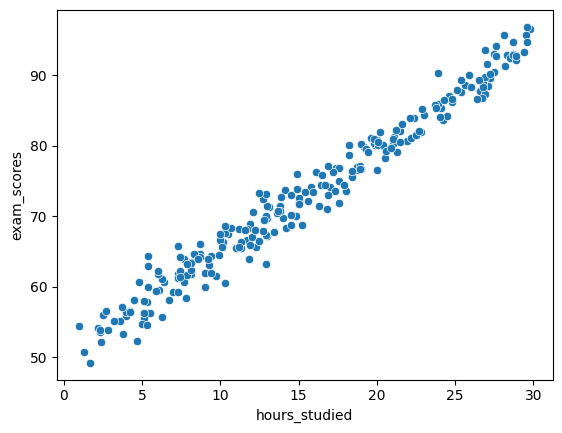

In [67]:
# Para visualizar las dos variables en cuestion vamos a realizar un scatterplot

sns.scatterplot(data=student_data, x='hours_studied', y='exam_scores')

Notamos claramente una relacion lineal fuerte entre las horas de estudio y la nota del examen final.

In [68]:
# Para corroborar lo dicho vamos a hacer una matriz de correlacion de Pearson

student_data.corr()

,hours_studied,exam_scores
hours_studied,1.000000,0.986093
exam_scores,0.986093,1.000000


En la interseccion de las variables, notamos un fuerte valor para R (coeficiente de Pearson) que nos dice que tenemos una asociacion lineal fuerte

PUNTO 2

In [69]:
modelo_estudio = smf.ols('exam_scores ~ hours_studied', data=student_data).fit()
print(modelo_estudio.summary())

                            OLS Regression Results                            
Dep. Variable:            exam_scores   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.972
Method:                 Least Squares   F-statistic:                     8555.
Date:                lun, 08 jun 2026   Prob (F-statistic):          2.11e-191
Time:                        09:42:02   Log-Likelihood:                -512.26
No. Observations:                 245   AIC:                             1029.
Df Residuals:                     243   BIC:                             1036.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        50.2541      0.278    180.576

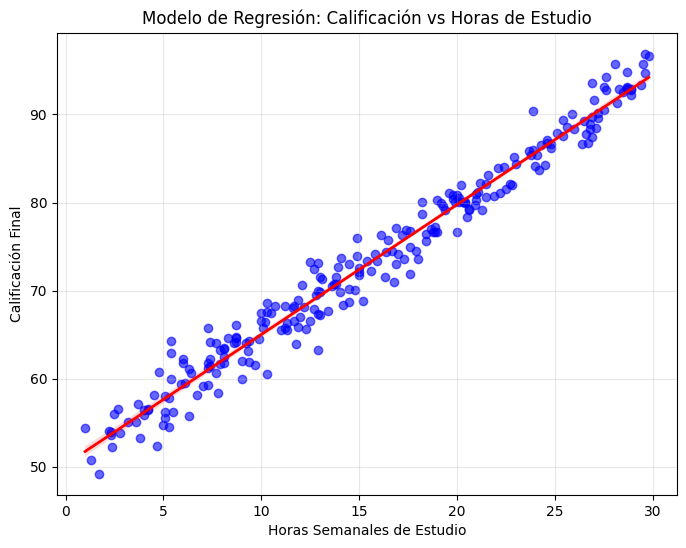

In [70]:
# Primero damos tamaño al grafico
plt.figure(figsize=(8, 6))

# Usamos regplot en lugar de scatterplot. 
# regplot dibuja los puntos (ítem 1) y automáticamente calcula y dibuja la línea de regresión.
sns.regplot(data=student_data, 
            x='hours_studied', 
            y='exam_scores', 
            scatter_kws={'color': 'blue', 'alpha': 0.6}, # Estilo de los puntos
            line_kws={'color': 'red', 'lw': 2})          # Estilo de la línea del modelo

plt.title('Modelo de Regresión: Calificación vs Horas de Estudio')
plt.xlabel('Horas Semanales de Estudio')
plt.ylabel('Calificación Final')
plt.grid(True, alpha=0.3)
plt.show()

PUNTO 3

El modelo ajustado nos queda de la siguiente manera 

    exam_scores = 50.25 + 1.48 * hours_studied

donde la constante representa la calificacion que se sacaria un estudiante si estudiara 0hs y la pendiente representa como mejoraria la

calificacion por cada hora estudiada

# EJERCICIO 3

In [71]:
penguins = pd.read_csv("datasets/Parte_2/penguins.csv")
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 344 non-null    int64  
 1   species            344 non-null    str    
 2   island             344 non-null    str    
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    str    
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), str(3)
memory usage: 30.2 KB


In [72]:
penguins.head()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


PUNTO 1

Realice un gráfico que le permita visualizar la relación que existe entre la longitud del pico y la longitud de la aleta de los pingüinos Palmer, según la especie. ¿Qué observa?

<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

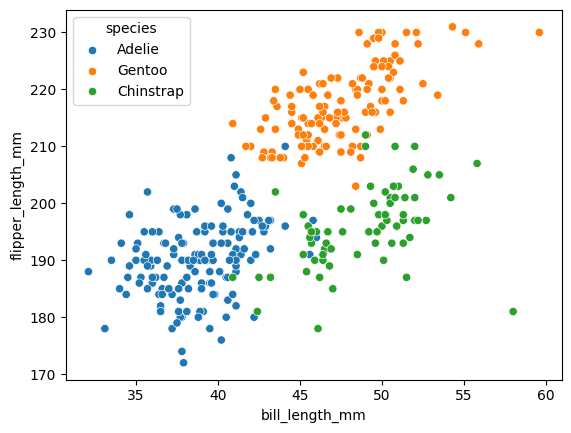

In [73]:
sns.scatterplot(data=penguins, x='bill_length_mm', y='flipper_length_mm', hue='species')

Al mirar la dispersion de los puntos y sus colores, podemos notar:

    Agrupamiento por especie: Hay tres "nubes" de puntos muy bien diferenciadas. La especie define fuertemente las proporciones corporales del pingüino.

    Tendencia general positiva: Si ignoráramos los colores, veríamos que en líneas generales, a medida que crece la aleta, también crece el pico.

PUNTO 2

Ajuste un modelo de regresión lineal que le permita predecir la longitud promedio del pico de los pingüinos Palmer a partir de la longitud de la aleta (modelo 1)

In [74]:
modelo_1_pen = smf.ols('bill_length_mm ~ flipper_length_mm', data=penguins).fit()
print(modelo_1_pen.summary())

                            OLS Regression Results                            
Dep. Variable:         bill_length_mm   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     257.1
Date:                lun, 08 jun 2026   Prob (F-statistic):           1.74e-43
Time:                        09:42:02   Log-Likelihood:                -968.98
No. Observations:                 342   AIC:                             1942.
Df Residuals:                     340   BIC:                             1950.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -7.2649      3.20

    Notamos que el modelo capta muy poco la variabilidad del largo del pico (variable respuesta), tan solo el 43.1%.

    El 56.9% restante de las variaciones se debe a otras causas que no están incluidas en tus variables predictoras, o simplemente a ruido aleatorio

PUNTO 3

A partir de las observaciones que realizó en el ítem 1, introduzca alguna modificación sobre el modelo inicial que le permita mejorar su capacidad predictiva para la longitud del pico de los pingüinos. Ajuste el nuevo modelo propuesto (modelo 2).



In [75]:
# Para una mejor prediccion, agregamos la especie como estimador para lograr ajustar esa diferencia entre los largos de los picos y aletas que nos encontramos entre especies

modelo_2_pen = smf.ols('bill_length_mm ~ flipper_length_mm + species', data=penguins).fit()
print(modelo_2_pen.summary())

                            OLS Regression Results                            
Dep. Variable:         bill_length_mm   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     390.0
Date:                lun, 08 jun 2026   Prob (F-statistic):          2.26e-109
Time:                        09:42:02   Log-Likelihood:                -809.56
No. Observations:                 342   AIC:                             1627.
Df Residuals:                     338   BIC:                             1642.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -2.0586 

    Notamos una mejora en la captacion de la variabilidad del largo del pico, con un 77.6%

PUNTO 4

¿Cuál de los dos modelos (modelo 1, modelo 2) proporciona un mejor ajuste? ¿Qué métrica utilizó para compararlos?

    El Modelo 2 proporciona un ajuste notablemente superior. La métrica utilizada para compararlos fue el coeficiente de determinación ($R^2$), y específicamente el $R^2$ ajustado (Adj. R-squared) dado que el Modelo 2 incorpora múltiples variables predictoras. Al introducir la variable categórica 'especie' en el Modelo 2, logramos un $R^2$ ajustado de 0.782, lo que indica que el modelo es capaz de explicar aproximadamente el 78% de la variabilidad en la longitud del pico de los pingüinos. Esta mejora sustancial era esperable basándonos en el gráfico de dispersión, el cual mostraba que especies como la Chinstrap presentaban relaciones de proporción pico-aleta muy distintas a las demás, una sutileza que el Modelo 1 (regresión simple) era incapaz de capturar.

PUNTO 5

Utilice el modelo seleccionado en el ítem anterior para predecir la longitud de pico que tendrá un pingüino Chinstrap de 17.6 mm de profundidad de pico, 191 mm de longitud de aleta, 3125 g de masa corporal y sexo masculino.

In [76]:
# Para predecir con los datos que se nos piden, debemos antes empaquetarlos en un DF para poder pasarselo al metodo .predict
datos_nuevo_pinguino = pd.DataFrame({
    'flipper_length_mm': [191],
    'species': ['Chinstrap']
})

# Le pedimos al modelo 2 que haga la predicción
prediccion_pico = modelo_2_pen.predict(datos_nuevo_pinguino)

# Imprimimos el resultado formateado
# prediccion_pico es una Serie, así que extraemos el primer valor con .iloc[0]
print(f"La longitud de pico predicha para este pingüino Chinstrap es: {prediccion_pico.iloc[0]:.2f} mm")

La longitud de pico predicha para este pingüino Chinstrap es: 47.80 mm


# EJERCICIO 7
El dataset USA_Housing.xlsx contiene la siguiente información sobre un conjunto de 5000 viviendas en Estados Unidos:

### PARTE I - Análisis exploratorio

1- Importe el dataset al entorno de trabajo y realice cualquier tarea de limpieza y adecuación del mismo que considere necesaria para su posterior análisis.

2- Realice un gráfico que le permita visualizar la distribución del precio de venta de las residencias que componen el dataset. En base al gráfico realizado, ¿cómo describiría la distribución de la variable en cuanto a sus características de simetría?

3- Construya un gráfico que le permita evaluar el grado de asociación lineal que existe entre las distintas variables cuantitativas que componen el dataset. En base al mismo, identifique la/s variable/s que se encuentran más fuertemente correlacionadas e informe e interprete la medida de asociación lineal correspondiente.

4- Elija uno de los pares de variables que identificó en el ítem anterior y realice un gráfico que le permita visualizar la relación general que existe entre las mismas.

In [77]:
viviendas_usa = pd.read_excel("datasets/Parte_2/USA_Housing.xlsx")
viviendas_usa

,avg_area_income,avg_area_house_age,avg_area_number_of_rooms,avg_area_number_of_bedrooms,area_population,price,address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


In [78]:
viviendas_usa.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   avg_area_income              5000 non-null   float64
 1   avg_area_house_age           5000 non-null   float64
 2   avg_area_number_of_rooms     5000 non-null   float64
 3   avg_area_number_of_bedrooms  5000 non-null   float64
 4   area_population              5000 non-null   float64
 5   price                        5000 non-null   float64
 6   address                      5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 499.6 KB


PUNTO 1

In [79]:
viviendas_usa.drop_duplicates(inplace=True)

# Limpieza de columnas inútiles para la regresión
# Eliminamos la dirección porque no aporta valor numérico
if 'address' in viviendas_usa.columns:
    viviendas_usa.drop(columns=['address'], inplace=True)

# Verificamos cómo quedó
print("\nDataset limpio:")
viviendas_usa.head()


Dataset limpio:


,avg_area_income,avg_area_house_age,avg_area_number_of_rooms,avg_area_number_of_bedrooms,area_population,price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


PUNTO 2

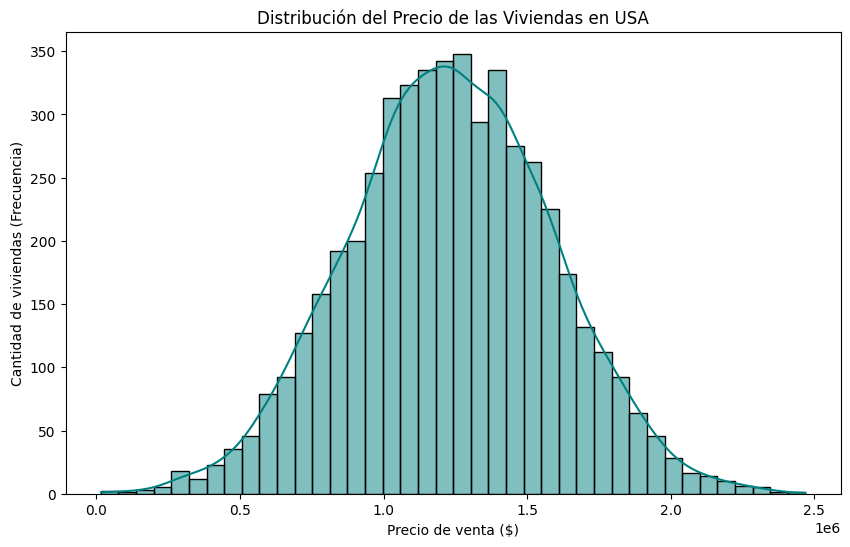

In [80]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Creamos el histograma con la curva de densidad (kde=True)
sns.histplot(viviendas_usa['price'], kde=True, color='teal', bins=40)

# Le ponemos títulos para que quede profesional
plt.title('Distribución del Precio de las Viviendas en USA')
plt.xlabel('Precio de venta ($)')
plt.ylabel('Cantidad de viviendas (Frecuencia)')

# Mostramos el gráfico
plt.show()

    Forma de Campana: La curva sube gradualmente hasta un pico central y luego baja de manera similar.

    Simetría: Si trazáramos una línea vertical imaginaria justo en el medio del pico (alrededor de 1.25 millones de dólares), veríamos que el lado izquierdo (precios más bajos) es prácticamente un reflejo en el espejo del lado derecho (precios más altos). Las "colas" a ambos lados descienden al mismo ritmo y no hay una extensión exagerada hacia ninguno de los extremos.

    Concentración Central: La gran mayoría de las casas se concentran en el rango de precios intermedios (entre 0.75 y 1.75 millones), lo cual es típico de variables que siguen un comportamiento normal.

    En base al gráfico realizado, la distribución de la variable price (precio de venta) se puede describir como simétrica. Presenta una forma de campana clásica (similar a una distribución normal), donde la mayor densidad de datos se concentra en el centro y las frecuencias disminuyen de manera equitativa y balanceada hacia ambos extremos (sin colas pesadas o sesgos evidentes hacia precios muy altos o muy bajos).

PUNTO 3

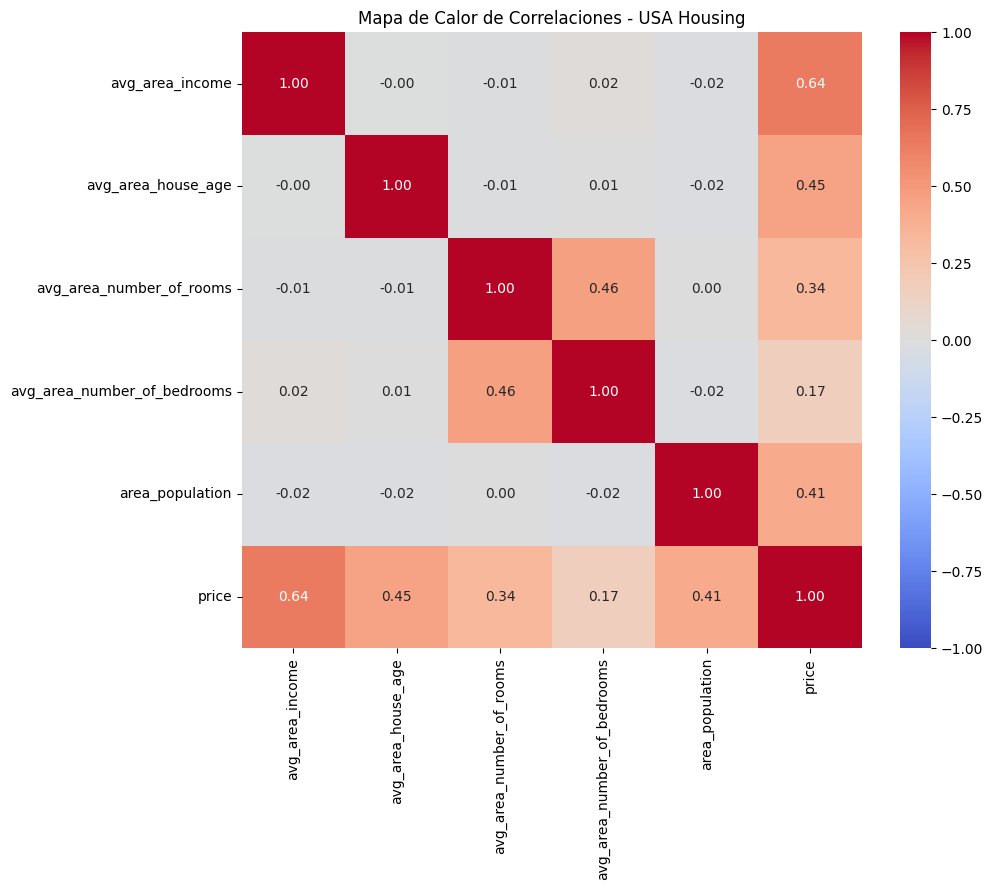

In [81]:
# Calculamos la matriz de correlación de Pearson
matriz_corr_viviendas = viviendas_usa.corr()

# Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 8))

# Creamos el mapa de calor
# annot=True muestra los números, cmap elige la paleta de colores
sns.heatmap(matriz_corr_viviendas, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Mapa de Calor de Correlaciones - USA Housing')
plt.show()

    En base a la matriz de correlaciones, la variable que se encuentra más fuertemente correlacionada con el precio de la vivienda (price) es el ingreso promedio de los residentes del área (avg_area_income), presentando un  coeficiente de correlación de Pearson de 0.64. Esta medida indica que existe una asociación lineal positiva moderada-fuerte entre ambas variables; es decir, a medida que aumenta el ingreso promedio de los residentes de una ciudad, el precio de venta de las viviendas en esa zona también tiende a aumentar de manera consistente.

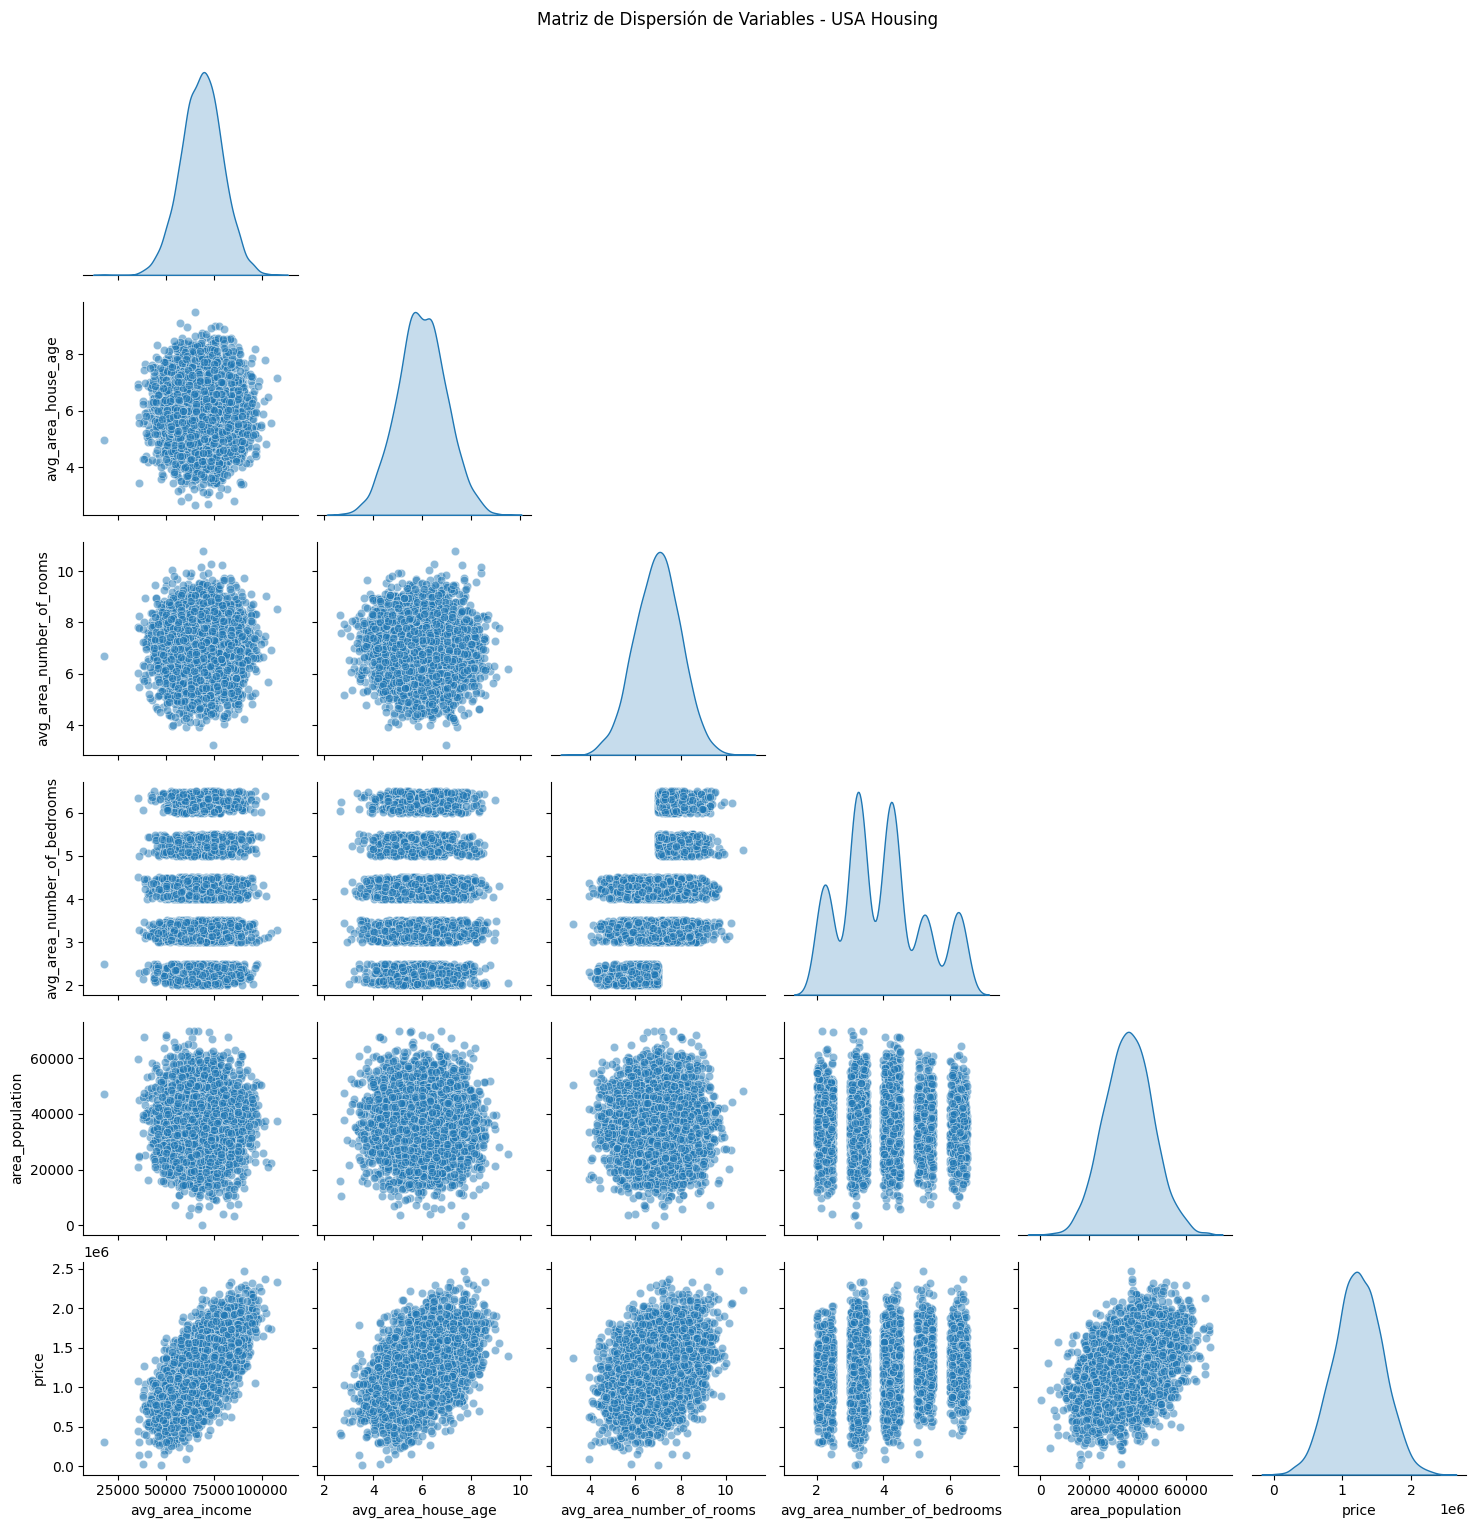

In [82]:
# Generamos la matriz de scatterplots
# Usamos corner=True para que solo dibuje la mitad inferior y no repita gráficos
# Usamos diag_kind='kde' para que en la diagonal nos muestre la distribución (la montañita) de cada variable
sns.pairplot(viviendas_usa, corner=True, diag_kind='kde', plot_kws={'alpha': 0.5})

# Le agregamos un título general (el y=1.02 es para que el título no se superponga con el gráfico)
plt.suptitle('Matriz de Dispersión de Variables - USA Housing', y=1.02)

# Mostramos el gráfico
plt.show()

PUNTO 4

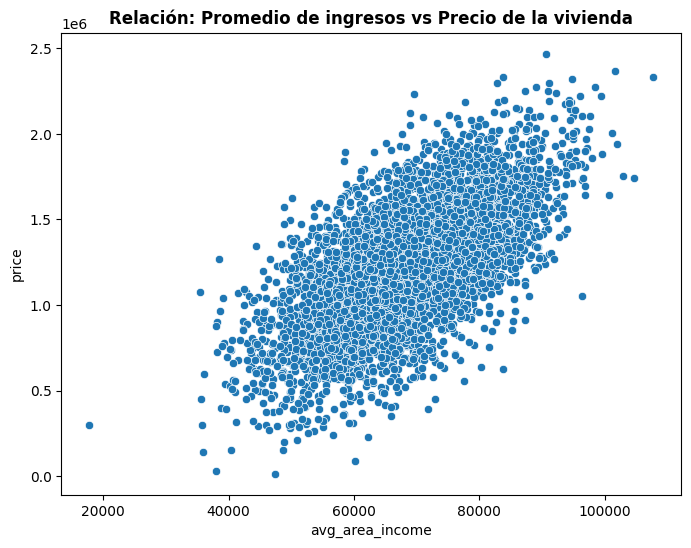

In [83]:
# Seleccionamos las variables price y avg_area_income
# Vamos a realizar un scatterplot para ver la relacion entre estas dos variables
plt.figure(figsize=(8, 6))

# Graficamos la relación general
sns.scatterplot(data=viviendas_usa, x='avg_area_income', y='price')
plt.title('Relación: Promedio de ingresos vs Precio de la vivienda', fontweight='bold')
plt.show()

    Al observar el gráfico de dispersión (scatterplot) entre avg_area_income y price, se confirma visualmente la relación descrita. Los datos forman una 'nube' de puntos con una clara tendencia ascendente de izquierda a derecha. Si bien existe cierta dispersión (lo cual es coherente con un coeficiente de 0.64 y no de 1.0), la dirección positiva de la relación es innegable.

### PARTE II - Ajuste de modelo

El objetivo principal de esta segunda parte es analizar si es factible ajustar un modelo de regresión lineal que permita predecir el precio de venta de una vivienda en Estados Unidos a partir de la cantidad de personas que viven en la ciudad en la que ésta se ubica y su ingreso promedio, así como las características generales de las viviendas en dicho lugar (antigüedad promedio/número promedio de ambientes/número de habitaciones promedio).

1- Comience ajustando el modelo completo, incluyendo la totalidad de las variables explicativas o independientes que resultan de interés. ¿Cuál/es de las variables incluidas contribuye/n significativamente a explicar la calidad de las viviendas? Justifique.

2- Ajuste un nuevo modelo tomando en cuenta su respuesta a la pregunta anterior.

En base al ajuste realizado, escriba dicho modelo en forma desarrollada e interprete cada uno de los coeficientes.

¿Qué medida utilizaría para comparar los dos modelos en cuanto a su bondad de ajuste? Interprete dicha medida para el modelo final.

Realice un gráfico de valores predichos vs. valores reales y comente lo observado.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

PUNTO 1

Del correlograma, podemos notar que, si bien sus valores de P son bajos, las variables que se relacionan linealmente (potenciales estimadores) con el precio son: avg_area_income, avg_area_house_age, avg_area_number_of_rooms y area_population. Plantearemos el primer modelo y veremos cuales aportan realmente.

In [88]:
modelo1_viviendas = smf.ols('price ~ avg_area_income + avg_area_house_age + avg_area_number_of_rooms + avg_area_number_of_bedrooms + area_population', data=viviendas_usa).fit()
print(modelo1_viviendas.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 1.119e+04
Date:                lun, 08 jun 2026   Prob (F-statistic):               0.00
Time:                        09:51:41   Log-Likelihood:                -64714.
No. Observations:                5000   AIC:                         1.294e+05
Df Residuals:                    4994   BIC:                         1.295e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

PUNTO 2

In [89]:
modelo2_viviendas = smf.ols('price ~ avg_area_income + avg_area_house_age + avg_area_number_of_rooms + area_population', data=viviendas_usa).fit()
print(modelo2_viviendas.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                 1.398e+04
Date:                lun, 08 jun 2026   Prob (F-statistic):               0.00
Time:                        09:52:20   Log-Likelihood:                -64714.
No. Observations:                5000   AIC:                         1.294e+05
Df Residuals:                    4995   BIC:                         1.295e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Ecuacion del modelo ajustado: 

$$price = -2.64 \cdot 10^6 + 21.58 \cdot avg\_area\_income + 1.66 \cdot 10^5 \cdot avg\_area\_house\_age + 1.22 \cdot 10^5 \cdot avg\_area\_number\_of\_rooms + 15.2 \cdot area\_population$$

### Intersección ($-2.64 \cdot 10^6$ o $-2,640,000$):
Matemáticamente: Es el valor esperado del precio de venta ($Y$) si todas las demás variables (ingreso, antigüedad, habitaciones y población) fueran iguales a cero.Prácticamente: En este contexto, no tiene una interpretación lógica, ya que no existen viviendas con 0 ambientes en ciudades sin población y con ingresos nulos. Simplemente sirve como un "ancla" matemática para posicionar la línea de regresión.
### Coeficiente de avg_area_income ($21.58$):
Manteniendo constantes la antigüedad de las casas, el número de ambientes y la población, por cada dólar adicional en el ingreso promedio de los residentes del área, se espera que el precio promedio de la vivienda aumente en $21.58.
### Coeficiente de avg_area_house_age ($1.66 \cdot 10^5$ o $166,000$):
Manteniendo constantes el ingreso, los ambientes y la población, por cada año adicional en la antigüedad promedio de las casas de la ciudad, se estima que el precio de venta de una vivienda aumentará en $166,000. (Esto sugiere que las zonas más establecidas o antiguas de este dataset están más valorizadas).
### Coeficiente de avg_area_number_of_rooms ($1.22 \cdot 10^5$ o $122,000$):
Si mantenemos fijos el ingreso, la antigüedad y la población, por cada ambiente adicional (en promedio) que tengan las casas de la zona, el precio esperado de venta se incrementa en $122,000.
### Coeficiente de area_population ($15.2$):
Asumiendo que las demás variables no cambian, por cada habitante adicional en la ciudad, el precio estimado de la vivienda sube $15.2. (Una mayor población genera más demanda, lo que encarece las propiedades).

    Para comparar la "bondad de ajuste" entre los 2 modelos, utilizaremos el Adj. R-squared, ya que este penaliza la complejidad del modelo y disminuira su valor si agregamos una variable insignificante a la mejora del ajuste.
    En este caso, para los 2 modelos tenemos un mismo valor en Adj. R-squared, pero nos quedamos con el segundo ya que es mas simple y no estariamos cargando el "peso muerto" de la variable avg_area_number_of_bedrooms.

## Grafico de Valores predichos vs Valores reales.

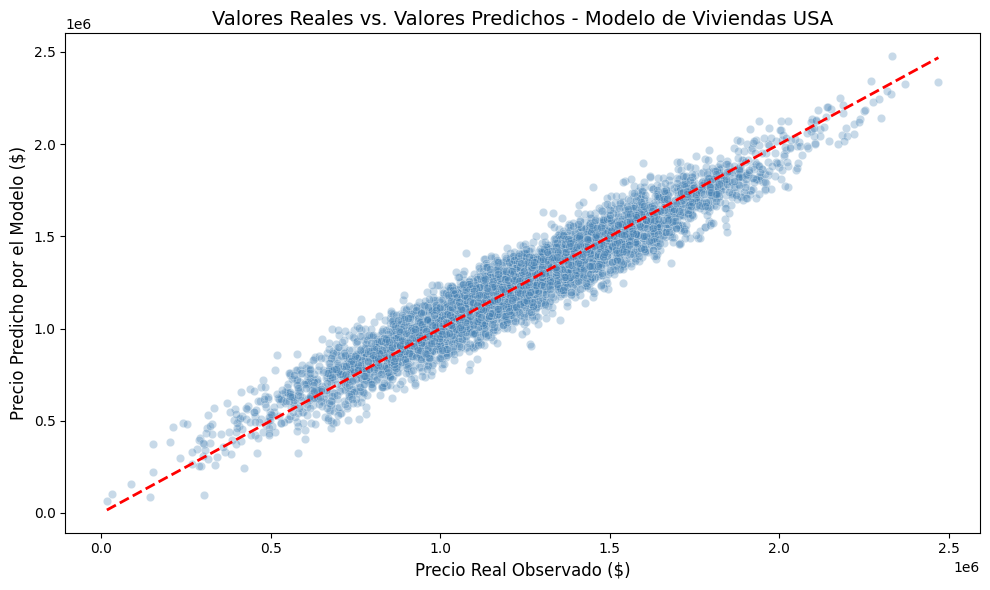

In [ ]:
# 1. Usamos el modelo para predecir los precios basados en nuestros datos de las casas
predicciones = modelo2_viviendas.predict(viviendas_usa)

# 2. Creamos la figura
plt.figure(figsize=(10, 6))

# 3. Hacemos el gráfico de dispersión: X = Precios Reales, Y = Predicciones
sns.scatterplot(x=viviendas_usa['price'], y=predicciones, alpha=0.3, color='steelblue')

# 4. Trazamos la línea de "Perfección" (donde Predicho = Real)
# Usamos el precio mínimo y máximo para que la línea cubra todo el gráfico
min_val = viviendas_usa['price'].min()
max_val = viviendas_usa['price'].max()
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

# 5. Etiquetas para que quede profesional
plt.title('Valores Reales vs. Valores Predichos - Modelo de Viviendas USA', fontsize=14)
plt.xlabel('Precio Real Observado ($)', fontsize=12)
plt.ylabel('Precio Predicho por el Modelo ($)', fontsize=12)

# Mostramos el gráfico
plt.tight_layout()
plt.show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# PRUEBAS PARA DETECTAR RED FLAGS
Vamos a hacer las pruebas con el dataset que teniamos sobre las horas de estudio de los alumnos

## Prueba de normalidad:

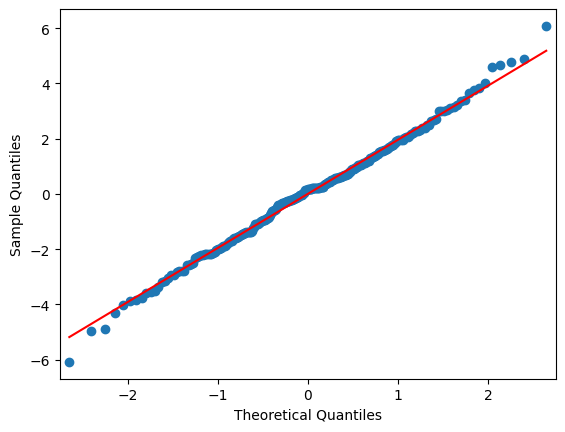

In [84]:
# Graficamos el Normal Q-Q Plot
sm.qqplot(modelo_estudio.resid, line='s')
plt.show()

Solo debemos buscar que los puntos azules (los residuos reales) caigan lo más pegados posible a la línea roja.

Para confirmarlo numéricamente sin depender del ojo, usamos la tabla del summary(): se revisa el valor Prob(JB) (el valor-p del test de Jarque-Bera) o el de Prob(Omnibus). Si esos valores son mayores a 0.05, los residuos se consideran normales y el modelo pasa la prueba

### 1. ¿Qué pasaría si NO siguiera una distribución normal?
Imagina que haces el histograma y, en lugar de una campana simétrica, ves una montaña totalmente recostada hacia la izquierda con una "cola" muy larga hacia la derecha (una distribución sesgada), o ves dos picos distintos (bimodal).

La Consecuencia Principal: La predicción general del modelo (la línea de tendencia) podría seguir siendo decentemente útil, pero pierdes la capacidad de hacer afirmaciones estadísticas confiables.

¿Por qué? Toda la matemática que calcula los p-values (P>|t|) y los intervalos de confianza asume que los errores son normales. Si no lo son, podrías estar viendo un p-value de 0.01 y celebrar que tu variable de TV es significativa, cuando en realidad ese número es un espejismo matemático.

Nota de color: Si tienes miles y miles de datos, este problema se vuelve un poco menos grave gracias a un concepto llamado "Teorema del Límite Central", pero en muestras pequeñas o medianas, invalida tus conclusiones.

### 2. ¿Qué pasaría si NO estuviera centrado en 0?
Imagina que la campana es perfecta, pero su pico máximo (el centro) está en el número +500 o -300 en lugar del 0.

La Consecuencia Principal: Significa que tu modelo tiene un sesgo sistemático (está parcializado). Si el centro está en los positivos, significa que el modelo sistemáticamente está subestimando la realidad (predice que venderás menos de lo que realmente terminas vendiendo). Si está en los negativos, tu modelo es demasiado optimista y siempre predice de más.

El secreto matemático (OLS): En los modelos de regresión lineal estándar (como el que hicimos, llamado Mínimos Cuadrados Ordinarios), la matemática fuerza artificialmente a que el promedio de los residuos sea exactamente cero al calcular la "Ordenada al origen" (el Intercept). Por lo tanto, si un día ves un histograma que no está centrado en cero, suele significar dos cosas: o forzaste al modelo a no usar una ordenada al origen, o le falta una variable tan pero tan importante que el modelo está completamente descalibrado.

## Prueba de heterocedasticidad: 

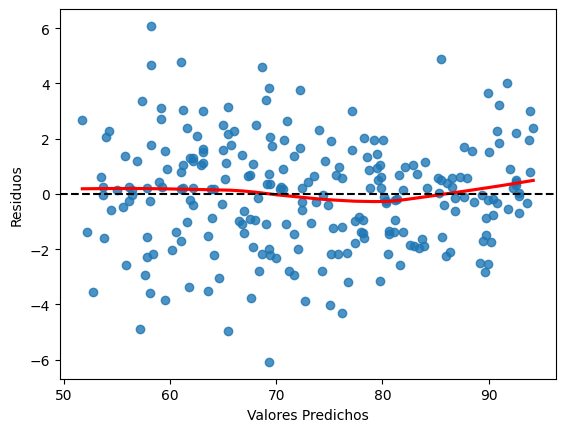

In [85]:
# Creamos el gráfico enfrentando predicciones vs residuos
sns.regplot(x=modelo_estudio.fittedvalues, y=modelo_estudio.resid, lowess=True, line_kws={'color': 'red'})

# Dibujamos una línea horizontal en el cero como referencia
plt.axhline(y=0, color='black', linestyle='--')

plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.show()

 Si los puntos formaran una figura de "embudo" (es decir, empiezan muy juntitos y se van separando cada vez más, o viceversa), significa que hay heterocedasticidad. Esto indicaria que el modelo es más impreciso en ciertos rangos de valores que en otros.

## Prueba de Outliers:

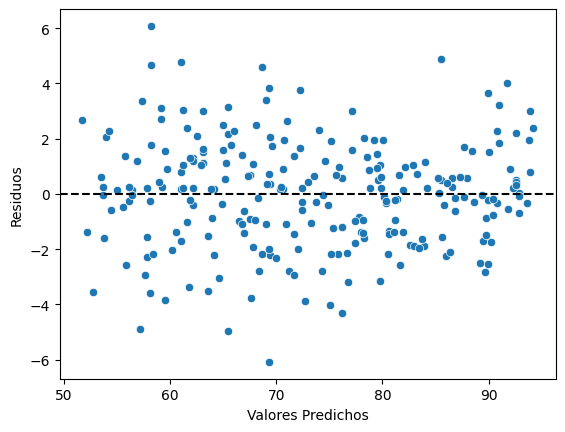

In [86]:
# Graficamos residuos vs valores predichos
sns.scatterplot(x=modelo_estudio.fittedvalues, y=modelo_estudio.resid)

# Línea de referencia en el cero
plt.axhline(y=0, color='black', linestyle='--')

plt.xlabel('Valores Predichos')
plt.ylabel('Residuos')
plt.show()

## DESCRIPCION DE SUMMARY :

### 1. RENDIMIENTO GENERAL DEL MODELO (Bloque superior)

R-squared: Porcentaje de la realidad que tu modelo logra explicar (0 a 1). Regla: Más cerca de 1, mejor.

Adj. R-squared: Igual que el anterior, pero castiga si agregás variables "basura". Regla: Si agregás una variable y este número baja, la variable no sirve.

F-statistic: Mide si el modelo entero es mejor que no tener modelo. Se lee junto con el de abajo.

Prob (F-statistic): El "valor p" de todo el modelo. Regla de oro: Debe ser < 0.05 para que el modelo tenga validez estadística.

### 2. LAS VARIABLES (Bloque central)

coef: El impacto de la variable. Cuánto sube/baja la predicción por cada unidad que aumenta esa variable. (El coef de Intercept es tu predicción base cuando todo lo demás vale 0).

std err: El margen de error de ese coeficiente. Regla: Queremos que sea chiquito.

P>|t| (Valor p individual): ¿Sirve esta variable para predecir? Regla de oro: < 0.05 significa que SIRVE. > 0.05 significa que NO sirve (es pura casualidad).

[0.025 - 0.975]: Intervalo de confianza del 95%. Regla: Si el intervalo cruza el cero (ejemplo: va de -2 a 5), la variable no es confiable.

### 3. CONTROL DE CALIDAD Y ERRORES (Bloque inferior)

Prob(Omnibus) y Prob(JB): Miden si los errores siguen una "campana de Gauss" normal. Regla: Acá queremos que sea > 0.05 (significa normalidad).

Skew (Asimetría): Si la campana de errores se inclina a un lado. Regla: El valor ideal es 0.

Kurtosis: Cantidad de valores atípicos. Regla: El valor ideal es alrededor de 3.

Durbin-Watson: Mide si un error se "contagia" al siguiente (autocorrelación). Regla: El valor ideal es 2. (Menos de 1.5 o más de 2.5 indica problemas).

Cond. No.: Detecta si metiste variables repetidas (multicolinealidad) o con escalas muy distintas. Regla: Valores mayores a 30 son alerta de problemas.